# Noncollinear magnetism, magnetic fields and constrained moments

With `nspin_mag = 4` the magnetization is a **vector field** rather than a number per
point. Two things follow. The symmetry group shrinks, because a rotation must map the
moments onto themselves as an *axial* vector and some operations survive only when
combined with time reversal. And there is now a direction to constrain or to push on,
which is what magnetic fields and constrained moments are for.

The density is a $2\times 2$ matrix in spin space, and the magnetization is its projection
onto the Pauli matrices:

$$n_{\alpha\beta}(\mathbf r) = \tfrac{1}{2}\Big[
   n(\mathbf r)\,\delta_{\alpha\beta}
   + \mathbf m(\mathbf r)\cdot\boldsymbol\sigma_{\alpha\beta} \Big],
\qquad
\mathbf m(\mathbf r) = \sum_{n\mathbf k} f_{n\mathbf k}\,
   \psi^{\dagger}_{n\mathbf k}(\mathbf r)\,
   \boldsymbol\sigma\,\psi_{n\mathbf k}(\mathbf r)$$

A constraint is a penalty on that vector, and the field it exerts is the gradient of the
penalty:

$$E_{\rm pen} = \lambda \sum_I \big(\mathbf m_I - \mathbf m^{\rm fix}_I\big)^2,
\qquad
\mathbf B_I = -\frac{\partial E_{\rm pen}}{\partial \mathbf m_I}$$

bcc iron matches Quantum ESPRESSO to **2.8e-9 Ry** with LDA and with PBE; fields and all
of QE's constrained-moment schemes to **2e-7 Ry or better**.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.io.pwin import parse_pw_input, read_pw_input
from pypresso.scf.fields import MagneticField
from pypresso.scf.locals import LocalRegions
from pypresso.system import build_system
from pypresso.system.builder import local_moments
from pypresso.system.symmetry import find_symmetries, magnetic_symmetries

NONCOLIN = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_noncolin")
PSEUDO, GENERATED = Path("../tests/data/pseudo"), Path("../tests/data/qe")


def load(text):
    """A calculator carrying the input's own mixing, ready to run."""
    pwin = parse_pw_input(text)
    return Calculator.from_text(
        text, PSEUDO, announce=False, conv_thr=1e-10, max_iterations=200,
        mixing_beta=float(pwin.get("electrons", "mixing_beta") or 0.7))


def scf(text, **options):
    calc = load(text)
    return calc, calc.get_scf(**options)


def namelist(text, extra):
    marker = text.lower().index("&system") + len("&system")
    return text[:marker] + "\n" + extra + text[marker:]


# The references are regenerated with the vendored pw.x: the shipped 2017 output of
# noncolin-constrain_atomic.in does not belong to the input beside it.
text = (NONCOLIN / "noncolin.in").read_text()
system = load(text).system
full = find_symmetries(system.cell, system.structure)
moments = local_moments(system.structure, 4, system.starting_magnetization,
                        system.angle1, system.angle2)
magnetic = magnetic_symmetries(system.cell, system.structure, full, moments)
reference = read_qe_output(GENERATED / "reference.out.pw_noncolin-noncolin")

print("starting moment       %s" % np.round(moments[0], 4))
print("crystal point group   %d operations" % full.nsym)
print("magnetic group        %d operations (%d of them needing time reversal)"
      % (magnetic.nsym, sum(magnetic.time_reversed)))
print("k-points: input %d -> pypresso %d, QE %d"
      % (len(read_pw_input(NONCOLIN / "noncolin.in").card("K_POINTS").lines) - 1,
         system.kpoints.nk, len(reference.kpoints)))

starting moment       [0.5 0.  0. ]
crystal point group   48 operations
magnetic group        16 operations (8 of them needing time reversal)
k-points: input 11 -> pypresso 22, QE 22


## The limit that has to come out right

A noncollinear run whose moments all point along $z$ *is* the collinear run, and rotating
them all together must change nothing at all: without spin-orbit coupling the spin and the
lattice are not tied to each other, so the energy cannot depend on the direction. A
hydrogen atom, its moment placed along four different directions:

In [2]:
base = (GENERATED / "h-atom-lsda.in").read_text()
directions = {"z": (0.0, 0.0), "x": (90.0, 0.0), "y": (90.0, 90.0),
              "(1,1,1)": (54.7356103172, 45.0)}
energies, vectors = {}, {}
for label, (theta, phi) in directions.items():
    _, result = scf(base.replace(
        "    nspin = 2",
        "    noncolin = .true.\n    angle1(1) = %s, angle2(1) = %s" % (theta, phi)))
    energies[label] = result.total_energy
    vectors[label] = np.asarray(result.magnetization_vector)
_, collinear = scf(base)

print("%-12s %20s   moment (mu_B)" % ("moment along", "total energy (Ry)"))
for label, energy in energies.items():
    print("%-12s %20.12f   %s" % (label, energy, np.round(vectors[label], 4)))
print("%-12s %20.12f   %.4f (along z by construction)"
      % ("collinear", collinear.total_energy, collinear.magnetization))
print("\nspread over the four directions    %.1e Ry"
      % (max(energies.values()) - min(energies.values())))
print("noncollinear along z vs collinear  %.1e Ry"
      % abs(energies["z"] - collinear.total_energy))

moment along    total energy (Ry)   moment (mu_B)
z                 -0.946064951880   [-0.  0.  1.]
x                 -0.946064951862   [ 1. -0. -0.]
y                 -0.946064951904   [ 0.  1. -0.]
(1,1,1)           -0.946064951911   [0.5774 0.5774 0.5774]
collinear         -0.946064951854   1.0000 (along z by construction)

spread over the four directions    4.9e-11 Ry
noncollinear along z vs collinear  2.6e-11 Ry


## bcc iron, against Quantum ESPRESSO

LDA first, then PBE. A gradient correction to a vector density is taken in the **local
spin frame**: at each point the density matrix is rotated onto its own magnetization axis,
the collinear expression is applied there, and the potential is rotated back.

In [3]:
_, iron = scf(text)
print("%-16s %18s %18s %12s" % ("term", "pypresso", "QE", "difference"))
for term, value in reference.energy_terms.items():
    if term in iron.energy_terms:
        print("%-16s %18.8f %18.8f %12.2e"
              % (term, iron.energy_terms[term], value,
                 abs(iron.energy_terms[term] - value)))
print("%-16s %18.8f %18.8f %12.2e"
      % ("TOTAL", iron.total_energy, reference.total_energy,
         abs(iron.total_energy - reference.total_energy)))
print("moment  pypresso %s   QE %s"
      % (np.round(iron.magnetization_vector, 4), reference.magnetization_vector))

_, iron_pbe = scf((NONCOLIN / "noncolin-pbe.in").read_text())
reference_pbe = read_qe_output(GENERATED / "reference.out.pw_noncolin-noncolin-pbe")
print("\nPBE     pypresso %.9f Ry   QE %.9f Ry   difference %.1e"
      % (iron_pbe.total_energy, reference_pbe.total_energy,
         abs(iron_pbe.total_energy - reference_pbe.total_energy)))
print("        moment %.2f -> %.2f mu_B, which is why a magnetic comparison with the "
      "literature needs the gradient correction"
      % (np.linalg.norm(iron.magnetization_vector),
         np.linalg.norm(iron_pbe.magnetization_vector)))

/u/40/ladovj1/data/Documents/programs/claude/pypresso/pypresso/calculator.py:312: RuntimeWarning: tstress = .true. in the input, but forces and stress for a noncollinear or spin-orbit calculation are not implemented; nspin = 1 and nspin = 2 are, on norm-conserving, ultrasoft and PAW pseudopotentials. The SCF is unaffected and SCFResult.stress is None.
  self._scf = run_scf(self.system, self.pseudos,


term                       pypresso                 QE   difference
one-electron             8.92933178         8.92932731     4.47e-06
hartree                  6.13361506         6.13359228     2.28e-05
xc                     -26.12190861       -26.12188165     2.70e-05
ewald                  -44.64461207       -44.64461207     4.30e-09
smearing                 0.00388950         0.00388979     2.94e-07
TOTAL                  -55.69968434       -55.69968434     2.78e-09
moment  pypresso [ 3.1763  0.     -0.    ]   QE (3.18, -0.0, -0.0)



PBE     pypresso -55.939445673 Ry   QE -55.939445670 Ry   difference 2.8e-09
        moment 3.18 -> 3.47 mu_B, which is why a magnetic comparison with the literature needs the gradient correction


"The moment on this atom" has no exact meaning in a plane-wave code, since there are no
muffin tins to integrate over. What is reported is the magnetization integrated over a
sphere of the radius QE uses, which for iron holds about 60% of the valence charge, and it
matches QE's.

## Constraints

A constraint scheme adds a penalty for the moment being in the wrong place, and the field
it produces is the derivative of that penalty. Four schemes are available, constraining the
total moment, the moment on each atom, its direction only, or the total direction. Below is
the atomic-direction scheme.

In [4]:
rng = np.random.default_rng(20260820)
grid = (6, 5, 4)
rho = rng.normal(size=(4,) + grid) * 0.1
rho[0] = np.abs(rho[0]) + 0.5
weights = jnp.asarray(rng.uniform(size=(2,) + grid))
cosines, penalty = np.array([[0.3], [-0.6]]), 0.21

field = MagneticField(regions=LocalRegions(weights=weights, radii=(1.0,), scheme="qe"),
                      uniform=jnp.zeros(3), atomic=None, targets=jnp.asarray(cosines),
                      penalty=penalty, constraint="atomic direction")
v, _, _ = field.potential(jnp.asarray(rho), system.cell)

m_loc = np.asarray(field.local_moments(jnp.asarray(rho), system.cell))
m2 = np.zeros_like(m_loc)
for a in range(2):
    ma = np.linalg.norm(m_loc[a])
    xx = m_loc[a, 2] / ma - cosines[a, 0]
    m2[a, 0] = -xx * m_loc[a, 0] * m_loc[a, 2] / ma**3
    m2[a, 1] = -xx * m_loc[a, 1] * m_loc[a, 2] / ma**3
    m2[a, 2] = xx * (-m_loc[a, 2] ** 2 / ma**3 + 1.0 / ma)
qe_potential = 2.0 * penalty * np.einsum("anmk,ac->cnmk", np.asarray(weights), m2)

print("jax.grad against add_bfield's algebra: %.1e"
      % np.abs(np.asarray(v)[1:] - qe_potential).max())
print("the charge component is untouched:     %.1e" % np.abs(np.asarray(v)[0]).max())

print("\n%-18s %16s %16s %10s" % ("scheme", "pypresso (Ry)", "QE (Ry)", "difference"))
for name, scheme in (("noncolin-constrain_atomic.in", "atomic"),
                     ("noncolin-constrain_angle.in", "atomic direction"),
                     ("noncolin-constrain_total.in", "total")):
    _, result = scf((NONCOLIN / name).read_text(), conv_thr=1e-11)
    ref = read_qe_output(GENERATED / f"reference.out.pw_noncolin-{Path(name).stem}")
    print("%-18s %16.8f %16.8f %10.1e"
          % (scheme, result.total_energy, ref.total_energy,
             abs(result.total_energy - ref.total_energy)))

jax.grad against add_bfield's algebra: 2.2e-16
the charge component is untouched:     0.0e+00

scheme                pypresso (Ry)          QE (Ry) difference


atomic                 -55.69055703     -55.69055687    1.6e-07


atomic direction       -55.69968434     -55.69968434    2.7e-09


total                  -55.54266107     -55.54266124    1.7e-07


**The constraint's energy is not part of the reported total energy.** The penalty is a
device for reaching a state, not a term in the material's energy, so it is carried and
printed separately. Elk excludes its external field's energy by the same convention.

## A field whose job is to leave

The trick for reaching a magnetic state that a nonmagnetic starting guess would never
find: apply a field, halve it every iteration, and let it vanish. Nothing in the SCF breaks
spin symmetry on its own, so the hydrogen atom started unpolarized stays unpolarized
forever. With a fading field it lands on the magnetic solution to 1e-10 Ry, and what is
left at the end is a genuine zero-field state, which a field left switched on would not be.

run                               energy (Ry)    moment
started magnetic                 -0.946064952   1.00000
started nonmagnetic              -0.893648588   0.00000
nonmagnetic + fading field       -0.946064952   1.00000
nonmagnetic + field held on      -0.946014192   1.00000

the fading field lands on the magnetic answer to 5.0e-11 Ry; a field left on is 5.1e-05 Ry away


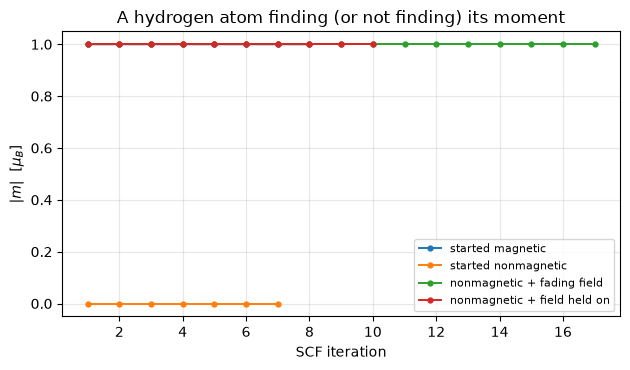

In [5]:
card = "LOCAL_MAGNETIC_FIELDS\n 0.0 0.0 0.10\n"
unmagnetised = base.replace("starting_magnetization(1) = 0.6",
                            "starting_magnetization(1) = 0.0")
runs = {}
_, runs["started magnetic"] = scf(base)
_, runs["started nonmagnetic"] = scf(unmagnetised)
_, runs["nonmagnetic + fading field"] = scf(
    namelist(unmagnetised, "    reducebf = 0.5\n") + card)
_, runs["nonmagnetic + field held on"] = scf(namelist(unmagnetised, "") + card)

print("%-30s %14s %9s" % ("run", "energy (Ry)", "moment"))
for label, result in runs.items():
    print("%-30s %14.9f %9.5f" % (label, result.total_energy, result.magnetization))
print("\nthe fading field lands on the magnetic answer to %.1e Ry; a field left on is "
      "%.1e Ry away"
      % (abs(runs["nonmagnetic + fading field"].total_energy
             - runs["started magnetic"].total_energy),
         abs(runs["nonmagnetic + field held on"].total_energy
             - runs["started magnetic"].total_energy)))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for label, result in runs.items():
    history = [abs(step["magnetization"]) for step in result.history]
    ax.plot(range(1, len(history) + 1), history, "o-", ms=3.5, lw=1.4, label=label)
ax.set_xlabel("SCF iteration"); ax.set_ylabel(r"$|m|$  [$\mu_B$]")
ax.set_title("A hydrogen atom finding (or not finding) its moment")
ax.legend(fontsize=8); ax.grid(alpha=0.3); fig.tight_layout()

## Fixing a moment instead of penalising it

A penalty leaves a residual force: the state sits where the penalty balances the
functional, which is not a stationary point of the functional itself. The fixed-spin-moment
scheme instead *searches* for the field at which the unconstrained functional puts the
moment where it was asked, so what converges is a genuine stationary state and the field it
found is itself a result, the field that would be needed to hold the material there.

How the search is run is worth more than a factor of ten. Nudging the field after every SCF
iteration reads a moment that has not finished responding to the previous nudge, and it
rings: 1380 iterations here. At converged density the moment is a smooth function of the
field, so holding the field until the SCF has converged and then stepping by the measured
susceptibility gives the same answer in **74**.

In [6]:
fsm = (GENERATED / "fe-fsm.in").read_text()
marker = fsm.index("&system") + len("&system")

print("%-8s %7s %14s %11s %17s"
      % ("rule", "iters", "B (Ry)", "m (mu_B)", "E (Ry)"))
for rule in ("secant", "elk"):
    source = fsm[:marker] + f"\n    fsm_update = '{rule}'\n" + fsm[marker:]
    _, result = scf(source, conv_thr=1e-8, max_iterations=2000)
    print("%-8s %7d %14.8f %11.6f %17.9f"
          % (rule, result.iterations, float(np.asarray(result.magnetic_field.uniform)[0]),
             result.magnetization, result.total_energy))

rule       iters         B (Ry)    m (mu_B)            E (Ry)


secant        73    -0.01096610    2.000220     -55.571534200


elk          246    -0.01096471    2.000541     -55.571537734


The same field to 4e-5 Ry and the same energy to 1e-5 Ry. The residue is the tolerance the
moment is held to divided by the 45 $\mu_B$/Ry susceptibility, since the two rules stop on
opposite sides of the target.

---
The tests behind this notebook: `tests/regression/test_noncollinear_magnetism.py`,
`tests/regression/test_magnetic_constraints.py`, `tests/unit/test_magnetic_fields.py`.